In [3]:
from google.colab import files
uploaded = files.upload()

Saving household_power_consumption.csv to household_power_consumption.csv


In [4]:
import pandas as pd

# Replace with your file name
data = pd.read_csv('household_power_consumption.csv')
data.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [5]:
# Replace '?' with NaN
data.replace('?', pd.NA, inplace=True)

# Drop missing values
data.dropna(inplace=True)

# Convert columns to numeric
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='ignore')

data.info()

/tmp/ipykernel_9969/1239236587.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data[col] = pd.to_numeric(data[col], errors='ignore')


<class 'pandas.core.frame.DataFrame'>
Index: 1044506 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1044506 non-null  object 
 1   Time                   1044506 non-null  object 
 2   Global_active_power    1044506 non-null  float64
 3   Global_reactive_power  1044506 non-null  float64
 4   Voltage                1044506 non-null  float64
 5   Global_intensity       1044506 non-null  float64
 6   Sub_metering_1         1044506 non-null  int64  
 7   Sub_metering_2         1044506 non-null  int64  
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 79.7+ MB


In [6]:
print(data.columns)

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')


In [7]:
data['Datetime'] = pd.to_datetime(
    data['Date'] + ' ' + data['Time'],
    dayfirst=True
)

data['hour'] = data['Datetime'].dt.hour
data['day'] = data['Datetime'].dt.day
data['month'] = data['Datetime'].dt.month

In [8]:
X = data[
    [
        'Voltage',
        'Global_intensity',
        'Sub_metering_1',
        'Sub_metering_2',
        'Sub_metering_3',
        'Global_reactive_power',
        'hour',
        'day',
        'month'
    ]
]

In [9]:
y = data['Global_active_power']

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:
from sklearn.metrics import mean_absolute_error, r2_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.012015235396789068
R2 Score: 0.9994127353619396


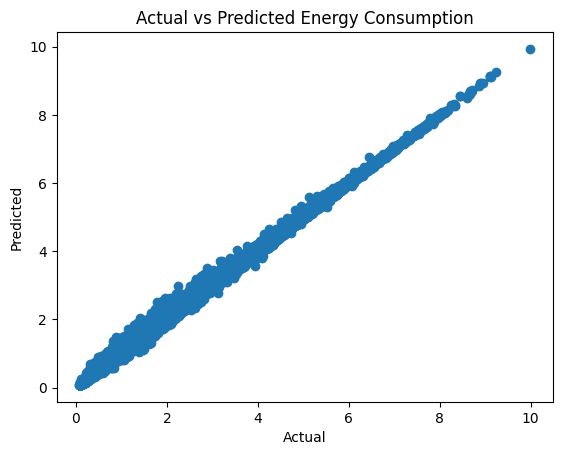

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Energy Consumption")
plt.show()

In [13]:
import pandas as pd

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                 Feature  Importance
1       Global_intensity    0.998398
0                Voltage    0.000442
5  Global_reactive_power    0.000391
6                   hour    0.000153
7                    day    0.000151
2         Sub_metering_1    0.000149
8                  month    0.000119
4         Sub_metering_3    0.000119
3         Sub_metering_2    0.000078


In [14]:
import joblib
joblib.dump(model, "model.pkl")

from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>